## Setup

Install the shared conda environment and editable package:

```bash
conda env create -f environment-train-eval.yml
conda activate paper-ai-diffraction-train-eval
pip install -e .
```

**Additional packages** required for this notebook (Fig S5 — HKL annotation):

```bash
conda install -c conda-forge cctbx-base         # symmetry-allowed reflections
pip install pyxtal spglib torchtune torchao     # crystal generation, Bravais centering, RoPE
```

> `torchtune` is imported unconditionally in the inline VIT definition but only active when `use_rope=True`.
> `pi7r8pah` uses `use_rope=False`, so `torchtune` is safe to install after the fact.

In [ ]:
import os
from pathlib import Path

# Locate repo root by searching for the 'configs' directory
cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in [cwd, *cwd.parents] if (p / 'configs').exists()), None
)
if REPO_ROOT is None:
    raise FileNotFoundError(f'Could not locate repo root from {cwd}')

FIGURE_DATA = str(REPO_ROOT / 'assets' / 'figure_data')
MODELS_DIR  = str(REPO_ROOT / 'external' / 'checkpoints')
DB_PATH     = os.path.join(FIGURE_DATA, 'intrep_crystal_xrd.db')
CSV_1K      = os.path.join(FIGURE_DATA, '1k_structures.csv')
CSV_INTERP  = os.path.join(FIGURE_DATA, 'interp_metadata_clean.csv')
CHECKPOINT  = os.path.join(MODELS_DIR,  'xrd_model_pi7r8pah.pth')

print(f'Figure data: {FIGURE_DATA}')
print(f'DB path    : {DB_PATH}')
print(f'Checkpoint : {CHECKPOINT}')


In [313]:
from numpy import sin, radians, tan, sqrt

In [317]:
from math import sin, radians, asin, degrees
import numpy as np
import datetime
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import spglib
import pyxtal
from cctbx import crystal

In [ ]:


def twotheta_to_d(twotheta, wavelength=1.541838):
    """Convert 2θ (degrees) to d-spacing (Å)."""
    return wavelength / (2 * sin(radians(twotheta) / 2))


def d_to_twotheta(d, wavelength=1.541838):
    """Convert d-spacing (Å) to 2θ (degrees)."""
    return 2 * degrees(asin(wavelength / (2 * d)))


def calcgaussian(x, fwhm):
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    return np.exp(-0.5 * ((x / sigma) ** 2))

def get_reflections(
    spacegroup_number,
    unit_cell,
    twotheta_min=5.0,
    twotheta_max=90.0,
    wavelength=1.541838,
):
    """
    Compute allowed XRD peak positions (2θ) from lattice + space group.

    Parameters
    ----------
    spacegroup_number : int
        International space group number (1–230)
    unit_cell : tuple
        (a, b, c, alpha, beta, gamma)
    twotheta_min, twotheta_max : float
        2θ range in degrees
    wavelength : float
        X-ray wavelength in Å

    Returns
    -------
    np.ndarray
        Sorted array of 2θ peak positions
    """

    
    # Build symmetry object
    symm = crystal.symmetry(
        unit_cell=unit_cell,
        space_group=spacegroup_number,
    )

    # Convert 2θ limits → d-spacing limits
    d_max = twotheta_to_d(twotheta_min, wavelength)
    d_min = twotheta_to_d(twotheta_max, wavelength)

    # Build allowed Miller indices (systematic absences handled here)
    miller_set = symm.build_miller_set(
        anomalous_flag=False,
        d_min=d_min,
        d_max=d_max,
    )

    uc = symm.unit_cell()

    # Convert hkl → 2θ
    twotheta = []
    for hkl in miller_set.indices():
        d_hkl = uc.d(hkl)
        twotheta.append(d_to_twotheta(d_hkl, wavelength))

    return np.array(sorted(twotheta))


In [315]:

class Peak(object):
    scaleFactor = 1
    def __init__(self, center, u, v, w, I, hkl=[None, None, None], shape="Gaussian", eta=0):
        self.center = center    # 2*theta position
        #note that the keyword argument is not great for hkl.  
        self.u = u
        self.v = v
        self.w = w
        self.I = I
        self.shape = shape
        self.eta = eta
        try:
            self.H = np.sqrt(u*(tan(radians(center/2))**2)
                          + v*tan(radians(center/2)) + w)
            self.scale = self.I * Peak.scaleFactor
        except ValueError:
            self.H = 0
            self.scale = 0
        self.hkl = hkl

    # __call__: returns the value of the Peak at some 2*theta positions
    def __call__(self, x):
        if self.shape.lower() == 'gaussian':
            return self.scale * calcgaussian(x-self.center, self.H)
            #return [self.scale * calcgaussian(value-self.center, self.H) for value in x]
        elif self.shape.lower() == 'pseudovoigt':
            return [self.scale * funcs.calcpseudovoigt(value-self.center, self.H, float(self.eta)) for value in x]
        elif self.shape.lower() == 'lorentzian':
            return [self.scale * funcs.calclorentzian(value-self.center, self.H) for value in x]
        else:
            print(f"Unsupported Peak-shape: {self.shape}\n")
            quit()
    def add(self, v, x):
        # only add to nearby 2*theta positions
        idx = (x>self.center-self.H*3) & (x<self.center+self.H*3)
        try:
            v[idx] += self.__call__(np.array(x)[idx])
        except:
            pass

In [316]:
def generate_diffraction_pattern_helper(spacegroup_number, unit_cell, wavelength, twotheta_min, twotheta_max, twothstep, u, v, w, peak_scale=1000):
    """
    Generate a diffraction pattern for a given space group and unit cell.

    Parameters:
        spacegroup_number (int): Space group number.
        unit_cell (tuple): Unit cell parameters (a, b, c, alpha, beta, gamma).
        wavelength (float): Wavelength of the X-ray beam.
        twotheta_min (float): Minimum 2-theta value.
        twotheta_max (float): Maximum 2-theta value.
        twothstep (float): Step size for 2-theta.
        u, v, w (float): Peak shape parameters.
        peak_scale (float): Scale factor for peak intensity.

    Returns:
        tuple: (twotheta, I) where `twotheta` is an array of 2-theta values and `I` is the corresponding intensity array.
    """
    # Create symmetry object
    symmetry = crystal.symmetry(unit_cell=unit_cell, space_group=spacegroup_number)

    # Calculate d-spacing range
    d_max = twotheta_to_d(twotheta_min, wavelength=wavelength)
    d_min = twotheta_to_d(twotheta_max, wavelength=wavelength)

    # Build Miller set and get allowed reflections
    miller_set = symmetry.build_miller_set(anomalous_flag=False, d_min=d_min, d_max=d_max)
    allowed_reflections = miller_set.indices()
    uc = symmetry.unit_cell()

    # Initialize 2-theta and intensity arrays
    twotheta = np.arange(twotheta_min, twotheta_max, twothstep)
    I = np.zeros(len(twotheta))

    # Calculate intensity for each allowed reflection
    for hkl in allowed_reflections:
        d_spacing = uc.d(hkl)
        twotheta_center = 2 * np.arcsin(wavelength / (2 * d_spacing)) * 180 / np.pi
        ps=np.random.uniform(5, peak_scale)
        peak = Peak(twotheta_center, u, v, w, ps, hkl=hkl, shape="Gaussian", eta=0)
        I += peak(twotheta)

    # Apply Lorentz correction
    lorentz = 1 / (np.sin(np.radians(twotheta)) * np.sin(np.radians(twotheta / 2)))
    I *= lorentz

    # Normalize intensity
    I = 1000 * I / I.max()

    return twotheta, I

In [327]:
def get_reflections_with_hkl(
    spacegroup_number,
    unit_cell,
    twotheta_min=5.0,
    twotheta_max=90.0,
    wavelength=1.541838,
):
    symm = crystal.symmetry(unit_cell=unit_cell, space_group=spacegroup_number)
    d_max = twotheta_to_d(twotheta_min, wavelength)
    d_min = twotheta_to_d(twotheta_max, wavelength)
    miller_set = symm.build_miller_set(anomalous_flag=False, d_min=d_min, d_max=d_max)
    uc = symm.unit_cell()

    results = []
    for hkl in miller_set.indices():
        d_hkl = uc.d(hkl)
        tt = d_to_twotheta(d_hkl, wavelength)
        results.append((tt, hkl))

    # Sort by 2θ
    results.sort(key=lambda x: x[0])
    twotheta = np.array([r[0] for r in results])
    hkls = [r[1] for r in results]
    return twotheta, hkls

In [334]:
def plot_pattern_with_hkl_attn_offset_no_limit(
    twotheta_pattern,
    intensity_pattern,
    twotheta_peaks,
    hkls,
    attn_profile=None,
    n_labels=10,
    sample_index=0,
    pattern_id=None,
    crystal_system=None,
    min_x_sep=1.0,
    y_step=0.06,
):
    """
    XRD pattern with attention overlay and staggered HKL annotations.
    Pass n_labels=0 to label all HKLs.
    """
    peak_max = intensity_pattern.max()
    hkl_buffer = 0.20 * peak_max if n_labels == 0 else (0.20 * peak_max if n_labels > 0 else 0.10 * peak_max)
    y_max = peak_max + hkl_buffer

    fig, ax = plt.subplots(figsize=(20, 8))

    if attn_profile is not None:
        attn_norm = (attn_profile - attn_profile.min()) / (attn_profile.max() - attn_profile.min() + 1e-8)
        num_bins = 50
        bin_edges = np.linspace(twotheta_pattern[0], twotheta_pattern[-1], num_bins + 1)
        bin_indices = np.digitize(twotheta_pattern, bin_edges) - 1
        for i in range(num_bins):
            mask = bin_indices == i
            if np.any(mask):
                ax.fill_between(
                    twotheta_pattern[mask], 0, y_max,
                    color=(1.0, 0, 0, attn_norm[mask].mean()),
                    step='mid'
                )

    ax.plot(twotheta_pattern, intensity_pattern, 'k-', linewidth=0.8)

    peak_intensities = np.interp(twotheta_peaks, twotheta_pattern, intensity_pattern)
    top_idx = np.arange(len(hkls)) if n_labels == 0 else np.argsort(peak_intensities)[-n_labels:]
    print(f"Total HKLs: {len(top_idx)}")

    placed = []
    for i in top_idx:
        h, k, l = hkls[i]
        x = twotheta_peaks[i]
        base_y = peak_intensities[i] + 0.02 * peak_max

        y = base_y
        for px, py in placed:
            if abs(x - px) < min_x_sep:
                y = max(y, py + y_step * peak_max)
        placed.append((x, y))

        ax.annotate(
            f"({h}{k}{l})",
            xy=(x, peak_intensities[i]),
            xytext=(x, y),
            xycoords='data',
            textcoords='data',
            ha='center',
            va='bottom',
            fontsize=6,
            rotation=45,
            arrowprops=dict(arrowstyle="-", color='gray', lw=0.5),
        )

    ax.set_ylim(0, y_max)
    ax.set_xlabel("2θ (degrees)")
    ax.set_ylabel("Intensity")
    ax.set_title(f"XRD Pattern {pattern_id} - Index {sample_index} - {crystal_system}")
    plt.tight_layout()
    plt.show()


In [342]:
def project_attention_to_2theta(attn_map, spec_length, two_theta_range):
    """
    Project attention weights back to 2θ domain.
    Ensures output length exactly matches spectrum length.
    Args:
        attn_map: torch.Tensor (num_heads, num_tokens, num_tokens)
        spec_length: int, length of spectrum (e.g. 3041)
        two_theta_range: tuple (min_2θ, max_2θ)
    Returns:
        two_theta: np.array of shape (spec_length,)
        attn_profile: np.array of shape (spec_length,)
    """
    # average attention across heads and CLS → patch tokens
    attn_cls = attn_map.mean(0)[0, 1:]  # (num_patches,)
    attn_cls = attn_cls / attn_cls.sum()

    # interpolate attention to exactly match spectrum length
    attn_profile = np.interp(
        np.arange(spec_length),
        np.linspace(0, spec_length - 1, len(attn_cls)),
        attn_cls.cpu().numpy()
    )

    # create two_theta to exactly match spec_length
    two_theta = np.linspace(two_theta_range[0], two_theta_range[1], spec_length)

    return two_theta, attn_profile

In [338]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchtune.modules import RotaryPositionalEmbeddings
from functools import partial

class EncoderBlock(nn.Module):
    def __init__(self,
                 dim,
                 num_heads,
                 mlp_ratio=4.,
                 qkv_bias=False,
                 qk_scale=None,
                 drop_ratio=0.,
                 attn_drop_ratio=0.,
                 drop_path_ratio=0.,
                 act_layer=nn.GELU,
                 norm_layer=nn.LayerNorm,
                 use_rope=False):
        super(EncoderBlock, self).__init__()
        self.norm1 = norm_layer(dim)
        self.use_rope = use_rope
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, qk_scale=qk_scale,
                              attn_drop_ratio=attn_drop_ratio, proj_drop_ratio=drop_ratio, use_rope=use_rope)
        self.drop_path = DropPath(
            drop_path_ratio) if drop_path_ratio > 0. else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim,
                       act_layer=act_layer, drop=drop_ratio)

    # def forward(self, x):
    #     x = x + self.drop_path(self.attn(self.norm1(x)))
    #     x = x + self.drop_path(self.mlp(self.norm2(x)))
    #     return x
    
    def forward(self, x, return_attn=False):
        # compute attention output
        # attn_out = self.attn(self.norm1(x))

        if return_attn:
            attn_out, attn_map = self.attn(self.norm1(x), return_attn=True)
        else:
            attn_out = self.attn(self.norm1(x))
            attn_map = None

        x = x + self.drop_path(attn_out)
        x = x + self.drop_path(self.mlp(self.norm2(x)))

        if return_attn:
            return x, attn_map  # return the attention map, not projected output
        else:
            return x

class Attention(nn.Module):
    def __init__(self,
                 dim,
                 num_heads=2,
                 qkv_bias=False,
                 qk_scale=None,
                 attn_drop_ratio=0.,
                 proj_drop_ratio=0.,
                 use_rope=False):
        super(Attention, self).__init__()
        self.use_rope = use_rope

        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = qk_scale or self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop_ratio)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop_ratio)

        if self.use_rope:
#            print("Using RoPE")
            self.rope = RotaryPositionalEmbeddings(self.head_dim)

    def forward(self, x, return_attn=False):
        # [batch_size, num_patches + 1, total_embed_dim]
        B, N, C = x.shape
        # qkv(): -> [batch_size, num_patches + 1, 3 * total_embed_dim]
        # reshape: -> [batch_size, num_patches + 1, 3, num_heads, embed_dim_per_head]
        # permute: -> [3, batch_size, num_heads, num_patches + 1, embed_dim_per_head]
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        # [batch_size, num_heads, num_patches + 1, embed_dim_per_head]
        # make torchscript happy (cannot use tensor as tuple)
        q, k, v = qkv[0], qkv[1], qkv[2]
        # transpose: -> [batch_size, num_heads, embed_dim_per_head, num_patches + 1]
        # @: multiply -> [batch_size, num_heads, num_patches + 1, num_patches + 1]

        if self.use_rope:
#            print(f"[RoPE] Rotary embedding applied")
            q, k = self.rope(q), self.rope(k)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        # @: multiply -> [batch_size, num_heads, num_patches + 1, embed_dim_per_head]
        # transpose: -> [batch_size, num_patches + 1, num_heads, embed_dim_per_head]
        # reshape: -> [batch_size, num_patches + 1, total_embed_dim]
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)

        # for inference
        if return_attn:
            # Return both the projected output and the raw attention weights
            return x, attn
        
        return x

class Mlp(nn.Module):

    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class PatchEmbed1D(nn.Module):
    def __init__(self, spec_length, patch_size, embed_dim):
        super().__init__()
        self.proj = nn.Conv1d(1, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.num_patches = spec_length // patch_size

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)  # (B, 1, L)

        # Pad to multiple of patch size
        pad_len = (self.patch_size - x.shape[-1] % self.patch_size) % self.patch_size
        if pad_len > 0:
            x = F.pad(x, (0, pad_len), value=0)

        x = self.proj(x)  # (B, embed_dim, num_patches)
        return x.transpose(1, 2)  # (B, num_patches, embed_dim)


'''
def Spectra_Embedding(x, spec_length, embed_dim):
    batch_size = x.shape[0]
    new_spec_length = (spec_length // embed_dim) * embed_dim
    x = x[:, :new_spec_length]
    x = torch.reshape(x, (batch_size, spec_length // embed_dim, embed_dim))
    return x

def Spectra_Embedding_old(x, spec_length, embed_dim):

    batch_size = x.shape[0]
    x = torch.reshape(x, (batch_size, spec_length // embed_dim, embed_dim))
    return x

def Spectra_Embedding_enlong(x, spec_length, embed_dim):
    batch_size = x.shape[0]
    remainder = spec_length % embed_dim
    if remainder != 0:
        pad = embed_dim - remainder
        x = F.pad(x, (0, pad))
    x = torch.reshape(x, (batch_size, -1, embed_dim))
    return x
'''
class MLPHead(nn.Module):
    """Optional non-linear head for ViT fine-tuning."""
    def __init__(self, embed_dim, num_classes, hidden_dim=None, drop=0.):
        super().__init__()
        hidden_dim = hidden_dim or embed_dim
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()
        self.drop = nn.Dropout(drop)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        return x
    
class VIT(nn.Module):
    def __init__(self, spec_length=2000, patch_size=10, num_output=1,
                 embed_dim=40, depth=12, num_heads=2, mlp_ratio=4.0, qkv_bias=True,
                 qk_scale=None, drop_ratio=0.,
                 attn_drop_ratio=0., drop_path_ratio=0., norm_layer=None,
                 act_layer=None, use_rope=False, use_mlp_head=False, mlp_head_hidden_dim=None):

        # MSTransformer
        super(VIT, self).__init__()
        self.num_classes = num_output
        self.spec_length = spec_length
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        norm_layer = norm_layer or partial(nn.LayerNorm, eps=1e-6)
        act_layer = act_layer or nn.GELU
        self.use_mlp_head = use_mlp_head
        self.mlp_head_hidden_dim = mlp_head_hidden_dim
        
        self.patch_embed = PatchEmbed1D(spec_length, patch_size, embed_dim)
        #self.num_patches = spec_length // patch_size
        # Calculate padded spec length
        padded_spec_length = (spec_length + patch_size - 1) // patch_size * patch_size
        self.num_patches = padded_spec_length // patch_size

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))  # +1 for cls
        self.pos_drop = nn.Dropout(p=drop_ratio)
        dpr = [x.item() for x in torch.linspace(0, drop_path_ratio, depth)]
        self.use_rope = use_rope

        self.blocks = nn.Sequential(*[
            EncoderBlock(dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, qkv_bias=qkv_bias, qk_scale=qk_scale,
                        drop_ratio=drop_ratio, attn_drop_ratio=attn_drop_ratio, drop_path_ratio=dpr[i],
                        norm_layer=norm_layer, act_layer=act_layer, use_rope=use_rope)
            for i in range(depth)
        ])
        self.norm = norm_layer(embed_dim)



        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(_init_vit_weights)

        if self.use_mlp_head:
            self.head = MLPHead(embed_dim, num_output, hidden_dim=mlp_head_hidden_dim, drop=drop_ratio)
        else:
            self.head = nn.Linear(embed_dim, num_output)


    def forward(self, x, return_cls_embedding=False):
        x = self.patch_embed(x)  # (B, num_patches, embed_dim)
        B, N, _ = x.shape

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)  # (B, N+1, embed_dim)

        if x.size(1) != self.pos_embed.size(1):
            # Resize positional embedding to match
            pos_embed = F.interpolate(
                self.pos_embed.transpose(1, 2),
                size=x.size(1),
                mode='linear',
                align_corners=False
            ).transpose(1, 2)
        else:
            pos_embed = self.pos_embed

        x = x + pos_embed

        x = self.pos_drop(x)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        cls_out = x[:, 0]

        return cls_out if return_cls_embedding else self.head(cls_out)

    def forward_with_attn(self, x, return_cls_embedding=False):
        """
        Forward pass that returns attention weights for CAM-style visualization.
        """
        x = self.patch_embed(x)  # (B, num_patches, embed_dim)
        B, N, _ = x.shape

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)  # (B, N+1, embed_dim)

        if x.size(1) != self.pos_embed.size(1):
            pos_embed = F.interpolate(
                self.pos_embed.transpose(1, 2),
                size=x.size(1),
                mode='linear',
                align_corners=False
            ).transpose(1, 2)
        else:
            pos_embed = self.pos_embed

        x = x + pos_embed
        x = self.pos_drop(x)

        attn_weights_list = []
        for blk in self.blocks:
            if hasattr(blk, "attn"):
                x, attn = blk(x, return_attn=True)  # block must support return_attn
                attn_weights_list.append(attn)
            else:
                x = blk(x)

        x = self.norm(x)
        cls_out = x[:, 0]

        return (cls_out if return_cls_embedding else self.head(cls_out), attn_weights_list)


def _init_vit_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.trunc_normal_(m.weight, std=.01)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.LayerNorm):
        nn.init.zeros_(m.bias)
        nn.init.ones_(m.weight)

def VIT_model(spec_length=2251,num_output: int = 1, patch_size=10, embed_dim=40, depth=12, num_heads=2, mlp_ratio=4.0, drop_ratio = 0., local_rank=0, use_rope=False, use_mlp_head=False, mlp_head_hidden_dim=None):
    model = VIT(spec_length=spec_length,
                              patch_size=patch_size,
                              embed_dim=embed_dim,
                              depth=depth,
                              num_heads=num_heads,
                              num_output=num_output,
                              mlp_ratio=mlp_ratio,
                              drop_ratio=drop_ratio,
                              use_rope=use_rope,
                              use_mlp_head=use_mlp_head,
                              mlp_head_hidden_dim=mlp_head_hidden_dim)

    return model

In [305]:
import sqlite3
import csv

# Connect to your SQLite database
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

structure_csv = CSV_1K

cursor.execute("""
    DROP TABLE IF EXISTS Structures
""")

# Load the CSV
with open(structure_csv, newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        # Create the table once before the loop
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS Structures (
                structure_id,
                source,
                generation_commit,
                extinction_group,
                crystal_system,
                space_group,
                composition,
                lattice_a,
                lattice_b,
                lattice_c,
                alpha,
                beta,
                gamma,
                atom_sites_json
            )
        """)

        # Then inside the loop, use only INSERT INTO
        cursor.execute("""
            INSERT INTO Structures (
                structure_id, source, generation_commit, extinction_group, crystal_system, 
                space_group, composition, lattice_a, lattice_b, lattice_c,
                alpha, beta, gamma, atom_sites_json
            ) VALUES ( ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (  row["structure_id"],
                row["source"],
                #row["source_id"],
                row["generation_commit"],
                #row["extinction_class"],
                int(row["extinction_group"]),
                row["crystal_system"],
                int(row["space_group"]),
                row["composition"],
                float(row["lattice_a"]),
                float(row["lattice_b"]),
                float(row["lattice_c"]),
                float(row["alpha"]),
                float(row["beta"]),
                float(row["gamma"]),
                #row["wyckoff_positions"],
                row["atoms"]))
        
# Commit and close
conn.commit()
conn.close()

print("All structure rows (with space group) loaded into the database successfully!")


All structure rows (with space group) loaded into the database successfully!


In [308]:
import csv

hdf5_to_structure = {}

with open(CSV_INTERP, newline="") as f:
    reader = csv.DictReader(
        row for row in f if not row.lstrip().startswith("#")
    )
    for row in reader:
        hdf5_to_structure[int(row["hdf5_index"])] = row["structure_id"]

print(hdf5_to_structure[1])

c39d7883-927b-470f-8035-34ee71681b8a


In [ ]:
sample_index = 85  # HDF5 index 85, monoclinic (Fig S5 paper sample)


In [ ]:
spec_length = 8501
num_classes = 99
patch_size = 25
embed_dim = 256
depth = 12
num_heads = 8
mlp_ratio = 4.0
drop_ratio = 0.0
use_rope = False
use_mlp = False
mlp_hidden_dim = 512
two_theta_min = 5.0
two_theta_max = 90.0
checkpoint = CHECKPOINT


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


In [341]:
# --- Load model ---
model = VIT_model(
    spec_length=spec_length,
    num_output=num_classes,
    patch_size=patch_size,
    embed_dim=embed_dim,
    depth=depth,
    num_heads=num_heads,
    mlp_ratio=mlp_ratio,
    drop_ratio=drop_ratio,
    use_rope=use_rope,
    use_mlp_head=use_mlp,
    mlp_head_hidden_dim=mlp_hidden_dim
)
# --- Load checkpoint ---
checkpoint = torch.load(checkpoint, map_location=device)

state_dict = checkpoint.get("model", checkpoint)  # handle case where it's nested

# Remove "module." prefix if present
from collections import OrderedDict
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k.replace("module.", "")  # remove "module." if it exists
    new_state_dict[name] = v

# Load into model
model.load_state_dict(new_state_dict, strict=False)

# Move to device
model = model.to(device)

model.eval()

VIT(
  (patch_embed): PatchEmbed1D(
    (proj): Conv1d(1, 256, kernel_size=(25,), stride=(25,))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): Sequential(
    (0): EncoderBlock(
      (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1024, out_features=256, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
    (1): EncoderBlock(
      (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (attn): Attenti

In [312]:
import sqlite3

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

cursor.execute("""
    SELECT *
    FROM Structures
    WHERE structure_id = ?
""", (hdf5_to_structure[sample_index],))

row = cursor.fetchone()
conn.close()

print(row)

('2a91c741-6c57-4b06-a775-8ccedcdbf0e3', 'PyXtal', '3e5b6cb27ee263b875831c6ddf53994b0f323cb1', 75, 'Trigonal', 146, 'Ra9Yb3', 10.977213436922739, 10.977213436922739, 6.592885200222869, 90.0, 90.0, 119.99999999999999, "[{'symbol': 'Yb', 'position': array([0.       , 0.       , 0.8903853])}, {'symbol': 'Yb', 'position': array([0.66666667, 0.33333333, 0.22371863])}, {'symbol': 'Yb', 'position': array([0.33333333, 0.66666667, 0.55705197])}, {'symbol': 'Ra', 'position': array([0.77378134, 0.24136247, 0.67659528])}, {'symbol': 'Ra', 'position': array([0.75863753, 0.53241887, 0.67659528])}, {'symbol': 'Ra', 'position': array([0.46758113, 0.22621866, 0.67659528])}, {'symbol': 'Ra', 'position': array([0.44044801, 0.5746958 , 0.00992861])}, {'symbol': 'Ra', 'position': array([0.4253042 , 0.86575221, 0.00992861])}, {'symbol': 'Ra', 'position': array([0.13424779, 0.55955199, 0.00992861])}, {'symbol': 'Ra', 'position': array([0.10711467, 0.90802913, 0.34326194])}, {'symbol': 'Ra', 'position': array

In [330]:
spacegroup_number = row[5]   # space_group
unit_cell = (
    row[7],                  # lattice_a
    row[8],                  # lattice_b
    row[9],                  # lattice_c
    row[10],                 # alpha
    row[11],                 # beta
    row[12],                 # gamma
)

twotheta_pattern, intensity_pattern = generate_diffraction_pattern_helper(
    spacegroup_number=spacegroup_number,
    unit_cell=unit_cell,
    wavelength=1.541838,
    twotheta_min=5.0,
    twotheta_max=90.0,
    twothstep=0.01,
    u=0.01,
    v=-0.01,
    w=0.02,
    peak_scale=1000,
)

In [329]:
twotheta_peaks, hkls = get_reflections_with_hkl(spacegroup_number, unit_cell)

In [344]:
intensity_pattern_padded = np.append(intensity_pattern, 0.0)


In [346]:
spectrum = torch.tensor(intensity_pattern_padded, dtype=torch.float32).unsqueeze(0).to(device)

In [347]:

# 2️⃣ Run model to get attention
with torch.no_grad():
    logits, attn_maps = model.forward_with_attn(spectrum)

last_attn = attn_maps[-1]
if isinstance(last_attn, (list, tuple)):
    last_attn = last_attn[0]
if last_attn.ndim == 4:  # B, heads, N, N
    last_attn = last_attn[0]

# 3️⃣ Project attention to spectrum length
two_theta, attn_profile = project_attention_to_2theta(
    last_attn,
    spec_length=spectrum.shape[1],
    two_theta_range=(two_theta_min, two_theta_max)
)


In [ ]:
two_theta = np.linspace(two_theta_min, two_theta_max, len(intensity_pattern))

attn_profile = np.interp(
    np.linspace(0, 1, len(intensity_pattern)),
    np.linspace(0, 1, len(attn_profile)),
    attn_profile
)


Total HKLs: 124


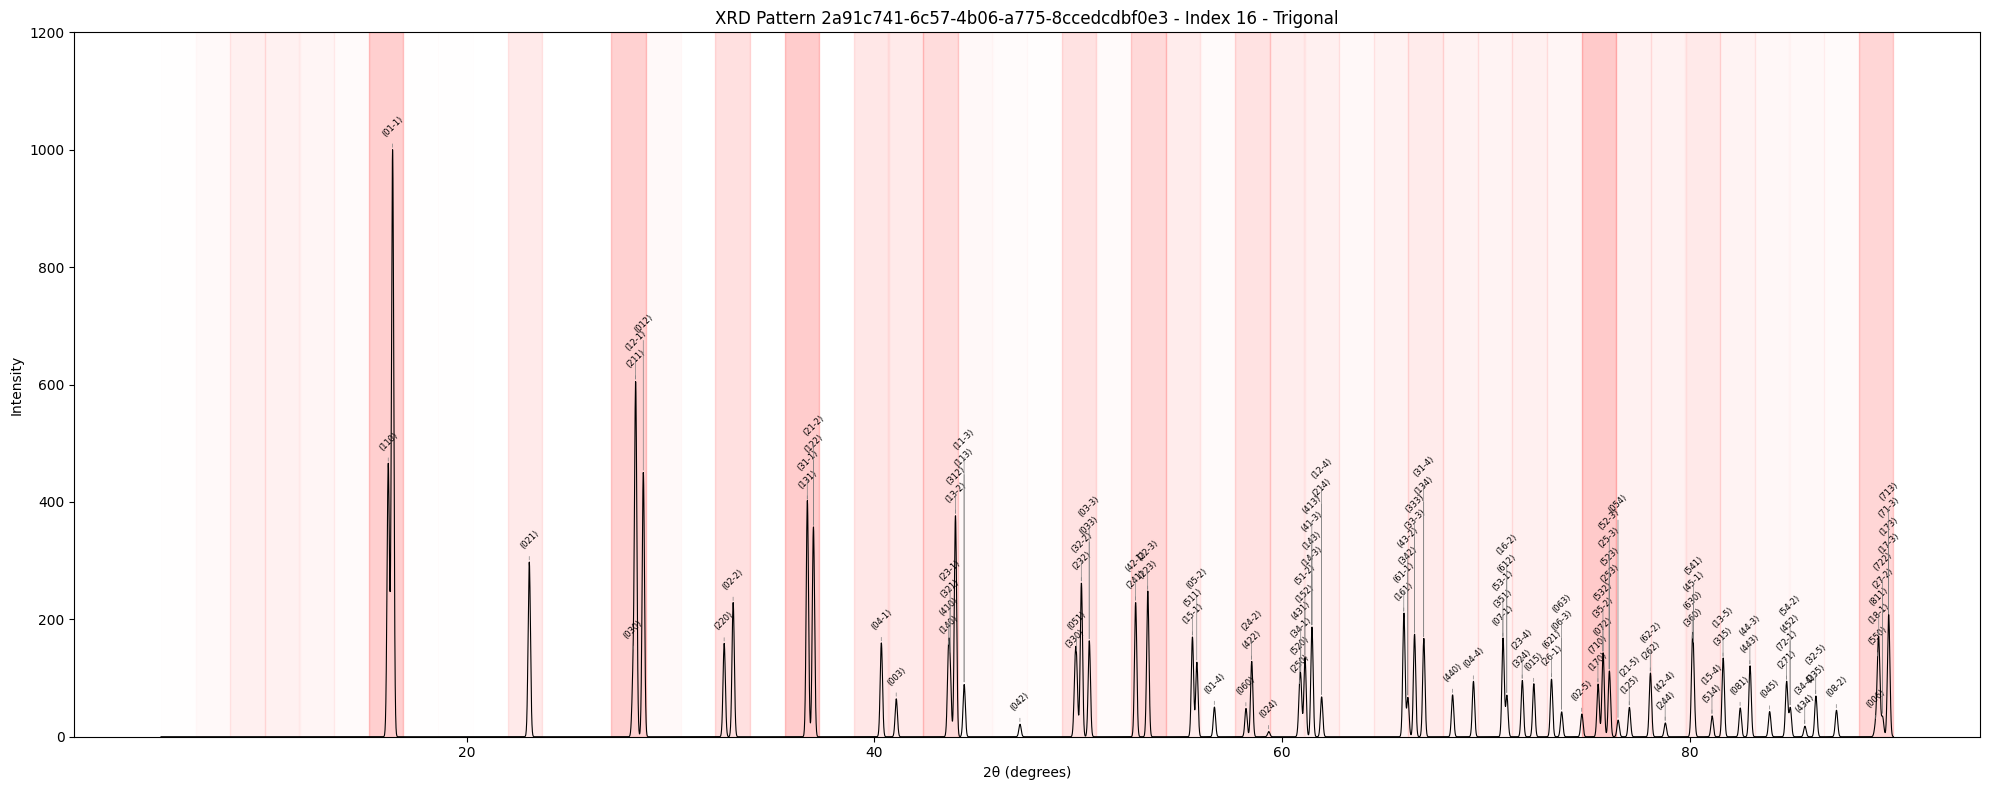

In [351]:

plot_pattern_with_hkl_attn_offset_no_limit(
    twotheta_pattern=two_theta,
    intensity_pattern=intensity_pattern,
    twotheta_peaks=twotheta_peaks,
    hkls=hkls,
    attn_profile=attn_profile,
    min_x_sep=0.5,
    y_step=0.03,
    n_labels=0,
    sample_index=sample_index,
    pattern_id=row[0],
    crystal_system=row[4]
)